<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/01-PyTorch/03-PyTorch-Object-Detection/01_R_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy
import torch
import os
from detection_utils import intersection_over_union, non_max_suppression

!pip -q install selectivesearch
import selectivesearch
import cv2

  Preparing metadata (setup.py) ... done


In [2]:
import kagglehub
path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

100%|██████████| 1.65G/1.65G [00:22<00:00, 79.4MB/s]

Extracting files...


In [6]:
import os
import xml.etree.ElementTree as ET

annotations_dir = None
images_dir = None

#The dataset is very messy or we are auto finding the folder's or dir's path we needs
for root_dir, dirs, files in os.walk(path):
    if "Annotations" in dirs:
        annotations_dir = os.path.join(root_dir, "Annotations")
    if "JPEGImages" in dirs:
        images_dir = os.path.join(root_dir, "JPEGImages")

if not annotations_dir or not images_dir:
    raise FileNotFoundError("Could not find Annotations or JPEGImages folders in the dataset.")

print(f"Found Annotations at: {annotations_dir}")
print(f"Found Images at: {images_dir}")
print("-" * 50)

#Extracting only the three classes for this small experiment
target_classes = {"person", "dog", "car"}
filtered_dataset = []

for xml_filename in os.listdir(annotations_dir):
    if not xml_filename.endswith(".xml"):
        continue

    xml_path = os.path.join(annotations_dir, xml_filename)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(images_dir, filename)

    target_objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name in target_classes:
            bndbox = obj.find("bndbox")
            xmin = int(float(bndbox.find("xmin").text))
            ymin = int(float(bndbox.find("ymin").text))
            xmax = int(float(bndbox.find("xmax").text))
            ymax = int(float(bndbox.find("ymax").text))

            target_objects.append({
                "class_name": class_name,
                "bbox": [xmin, ymin, xmax, ymax]
            })

    if len(target_objects) > 0:
        filtered_dataset.append({
            "image_path": image_path,
            "objects": target_objects
        })

print(f"Successfully processed {len(filtered_dataset)} images containing a person, dog, or car.")
print(f"Sample data: {filtered_dataset[0]}")

Found Annotations at: /root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctrainval_06-nov-2007/VOCdevkit/VOC2007/Annotations
Found Images at: /root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages
--------------------------------------------------
Successfully processed 2878 images containing a person, dog, or car.
Sample data: {'image_path': '/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctrainval_06-nov-2007/VOCdevkit/VOC2007/JPEGImages/003380.jpg', 'objects': [{'class_name': 'person', 'bbox': [8, 85, 248, 375]}, {'class_name': 'person', 'bbox': [245, 27, 500, 375]}]}


In [14]:
#Randomly picking 16 images with ground truth box for visuallization
# import random
# from google.colab.patches import cv2_imshow

# Loop for puting the box and class name on the img
# for i in range(16):
#   random_idx=random.randint(0,len(filtered_dataset))
#   img=cv2.imread(filtered_dataset[random_idx]["image_path"])
#   for obj in filtered_dataset[random_idx]["objects"]:
#     class_name = obj["class_name"]
#     bbox = obj["bbox"]
#     cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
#     cv2.putText(img, class_name, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

#   cv2_imshow(img)
#   cv2.waitKey(0)
#   cv2.destroyAllWindows()

<Figure size 1000x1000 with 0 Axes>

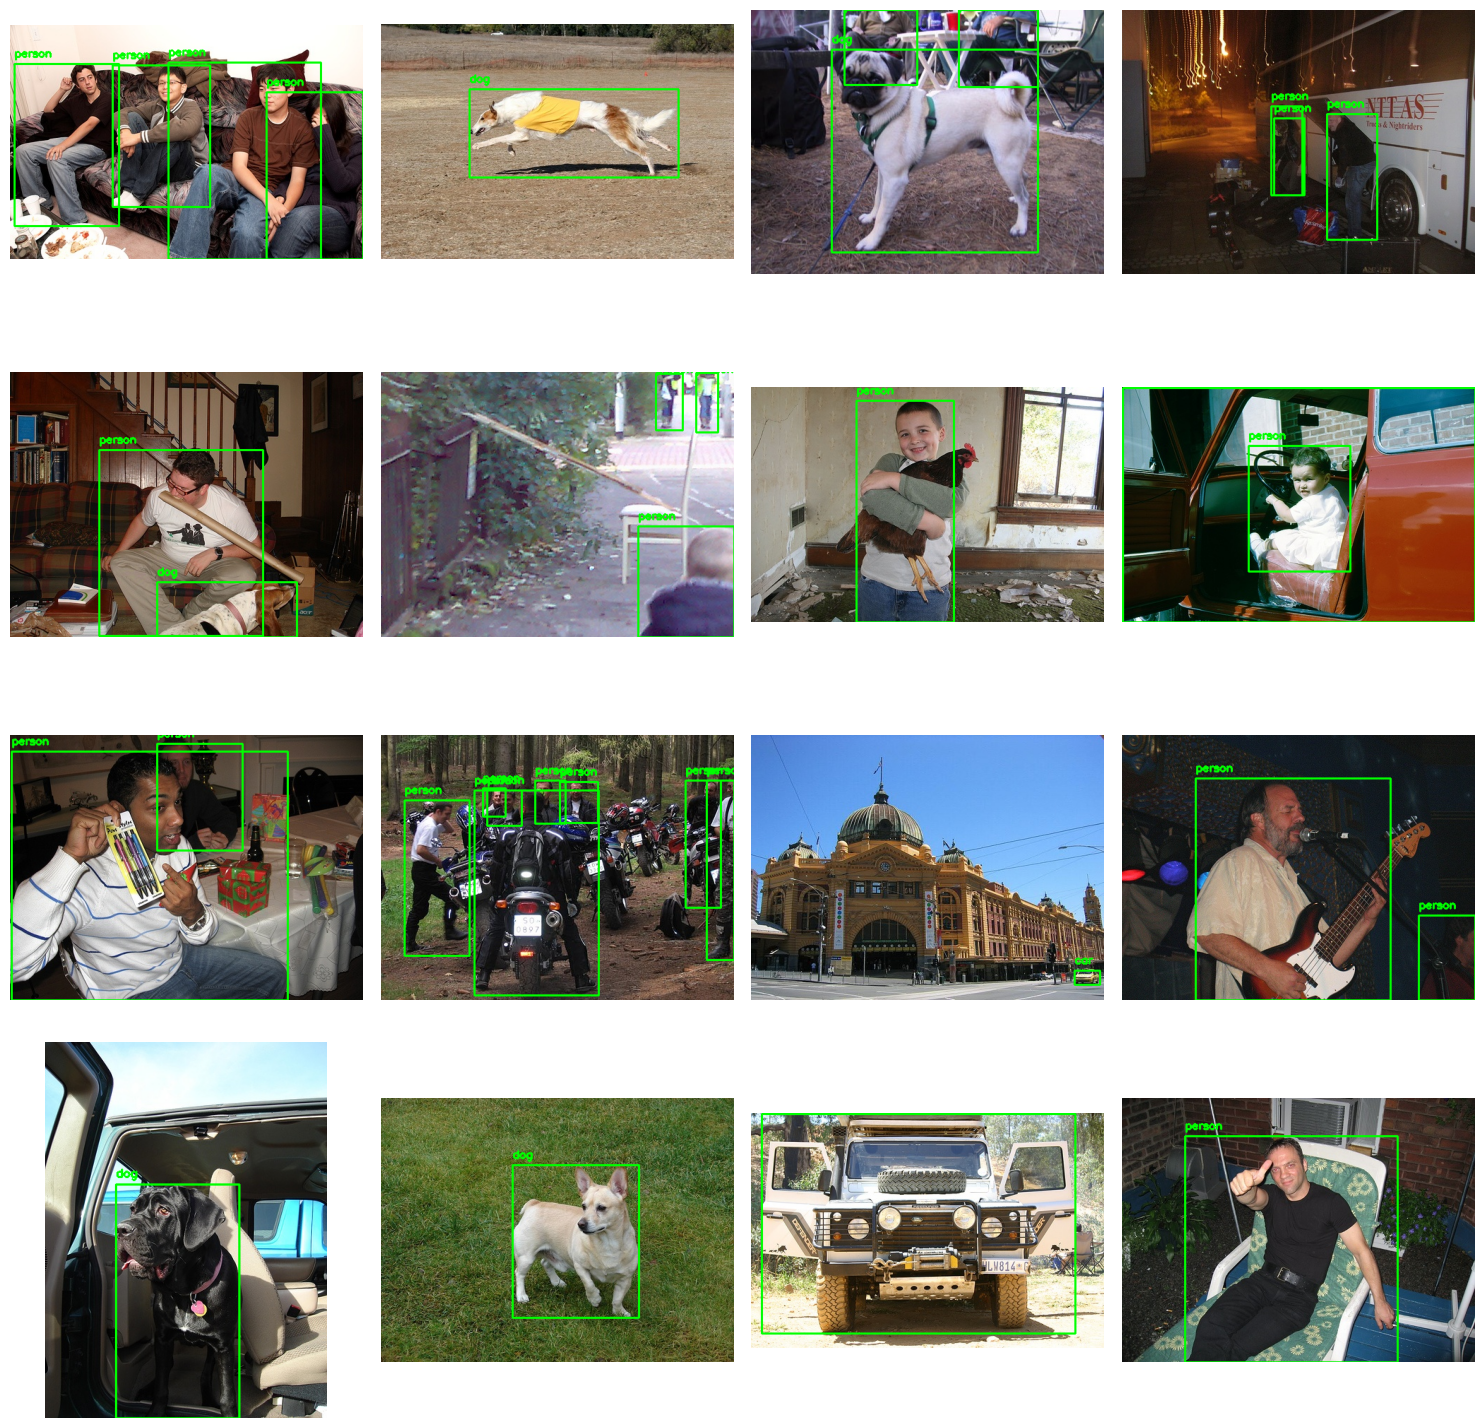

In [18]:
import random
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 10))

sample_indices = random.sample(range(len(filtered_dataset)), 16) # Using the random.sample rather than randint for 16 unique indices

# Create a 4x4 grid for plot
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

#Adding all the ground truth boxes for each img for visualization
for idx, ax in zip(sample_indices, axes):
    img = cv2.imread(filtered_dataset[idx]["image_path"])

    for obj in filtered_dataset[idx]["objects"]:
        class_name = obj["class_name"]
        bbox = obj["bbox"]

        cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
        cv2.putText(img, class_name, (bbox[0], max(0, bbox[1] - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.axis("off")

plt.tight_layout()

sns.despine()
plt.show()